# Linear and Quadratic Discriminant Analysis

**Versión para estudiantes.**  
Respeta el orden de la versión completa. Completa únicamente los espacios marcados con `# TU CÓDIGO AQUÍ`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
                            classification_report, roc_auc_score, roc_curve)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#!pip install xlrd

## 1. Selección de base de datos

**Pregunta 1.** ¿Por qué este archivo se debe leer con `pd.read_excel()` y no con `pd.read_csv()`?

porque el archivo esta en formato .xls y por eso se debe usar pd.read_excel(), mientras que pd.read_csv() se utiliza para archivos con formato .csv.

In [4]:
df = pd.read_excel("/content/drive/MyDrive/ciencicias de datos/modulo 4/Tareas/clase 4/UCI_Credit_Card.xls")
print(f'Dim: {df.shape}')
df.head()

Dim: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
#Valores nulos
# TU CÓDIGO AQUÍ
df.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


## 2. Análisis exploratorio de datos

**Pregunta 2.** Antes de modelar, ¿por qué conviene revisar nombres de columnas, valores nulos y distribución de la variable objetivo?

porque permite detectar errores, revisar los datos faltantes y conocer la distribucion de la variable objetivo antes de construir el modelo porque si tuvieramos un error pues lo podemos prevenir a que no pase

In [6]:
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [7]:
# Renombramos la variable objetivo

df = df.rename(columns = {'default payment next month': 'target'})
print(df['target'].value_counts())
print('\nFrecuencias relativas:')
print(df['target'].value_counts(normalize = True).round(4))

target
0    23364
1     6636
Name: count, dtype: int64

Frecuencias relativas:
target
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [8]:
# Estadísticos descriptivos
df.drop(columns = ['ID']).describe().T[['count', 'mean', 'std', 'min', 'max']].round(2)

,count,mean,std,min,max
LIMIT_BAL,30000.0,167484.32,129747.66,10000.0,1000000.0
SEX,30000.0,1.60,0.49,1.0,2.0
EDUCATION,30000.0,1.85,0.79,0.0,6.0
MARRIAGE,30000.0,1.55,0.52,0.0,3.0
AGE,30000.0,35.49,9.22,21.0,79.0
PAY_0,30000.0,-0.02,1.12,-2.0,8.0
PAY_2,30000.0,-0.13,1.20,-2.0,8.0
PAY_3,30000.0,-0.17,1.20,-2.0,8.0
PAY_4,30000.0,-0.22,1.17,-2.0,8.0
PAY_5,30000.0,-0.27,1.13,-2.0,8.0


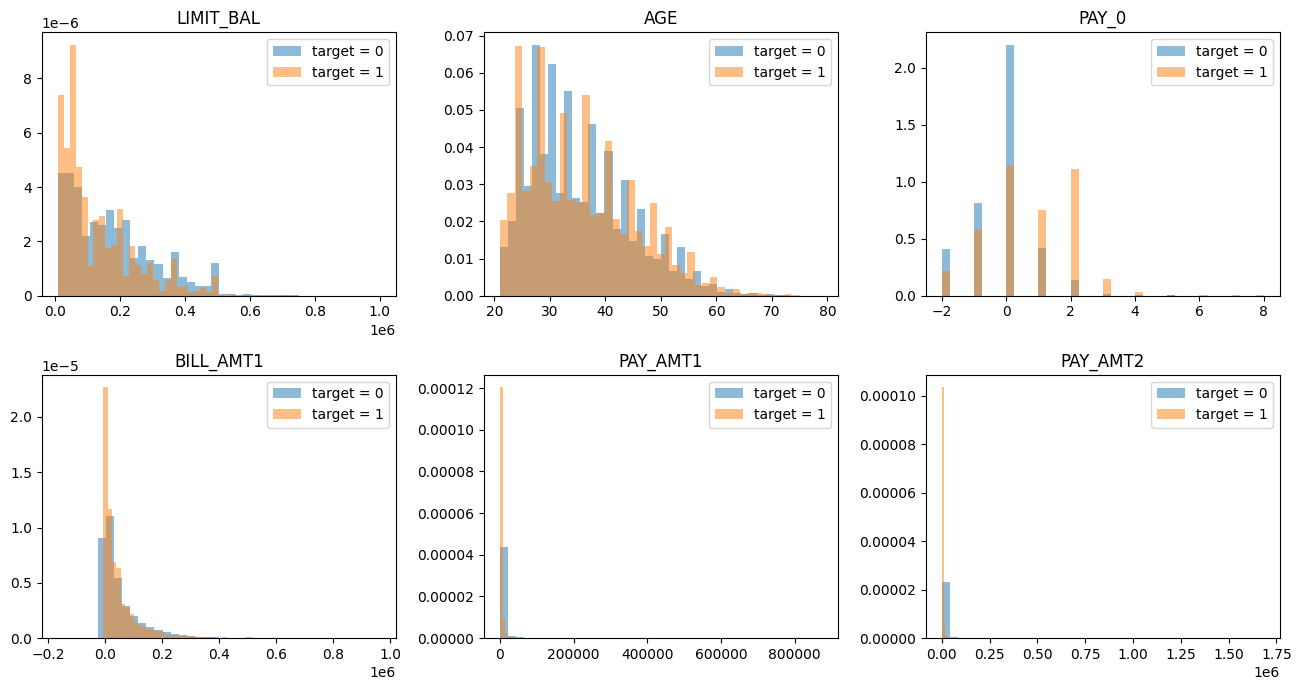

In [9]:
# Distribuciones por clase
vars = ['LIMIT_BAL', 'AGE', 'PAY_0', 'BILL_AMT1', 'PAY_AMT1', 'PAY_AMT2']
fig, axes = plt.subplots(2,3, figsize = (13,7))

for ax, v in zip(axes.ravel(), vars):
    for c in [0,1]:
        ax.hist(df.loc[df['target'] == c, v], bins = 40, alpha = 0.5 , label = f'target = {c}', density = True)
    ax.set_title(v); ax.legend()
plt.tight_layout()
plt.show()

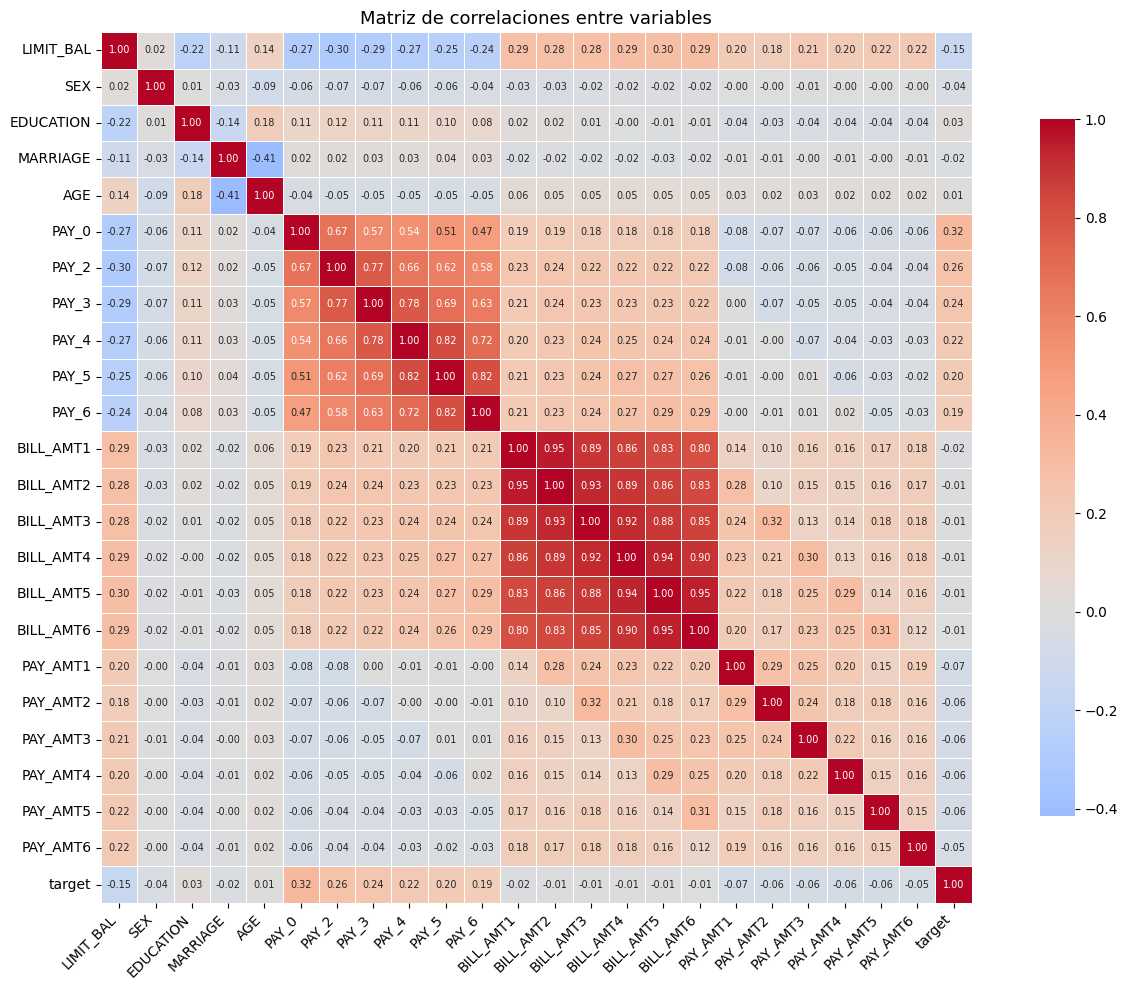

In [10]:
# Matriz de correlaciones
num = df.drop(columns = ['ID']).select_dtypes(include = 'number')
plt.figure(figsize=(14, 10))
corr_matrix = num.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, annot_kws={'size': 7})
plt.title('Matriz de correlaciones entre variables', fontsize=13)
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

In [11]:
# Correlación con la variable objetivo
corr = num.corr()['target'].drop('target').sort_values(key=abs, ascending = False)
print("Variables más correlacionadas con la vatiable objetivo:")
corr.head(10).round(4)

# Pregunta 3:
# ¿Qué variables parecen tener mayor relación lineal con target?
# Escribe tu interpretación en una celda Markdown debajo de esta celda.

Variables más correlacionadas con la vatiable objetivo:


,target
PAY_0,0.3248
PAY_2,0.2636
PAY_3,0.2353
PAY_4,0.2166
PAY_5,0.2041
PAY_6,0.1869
LIMIT_BAL,-0.1535
PAY_AMT1,-0.0729
PAY_AMT2,-0.0586
PAY_AMT4,-0.0568


PAY_0, PAY_2, PAY_3 y PAY_4 son las variables con mayor relacion lineal con target, mientras que LIMIT_BAL presenta una relacion negativa

## 3. Preparación de los datos

**Pregunta 4.** ¿Por qué separamos `X` y `y` antes de entrenar el modelo?
#porque X contiene las variables predictoras y y la variable objetivo que queremos predecir

**Pregunta 5.** ¿Por qué las variables `SEX`, `EDUCATION` y `MARRIAGE` se convierten en variables dummy?
#porque son variables categoricas y deben convertirse a valores numericos para que el modelo pueda utilizarlas

In [12]:
y = df['target']
X = df.drop(columns = ['ID', 'target'])
X = pd.get_dummies(X, columns = ['SEX', 'EDUCATION', 'MARRIAGE'], drop_first = True).astype(float)

#Entrenamiento/Prueba

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 67, stratify = y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')
print(f'{y_train.value_counts(normalize = True).round(3).to_dict()}')

Train: (24000, 30) | Test: (6000, 30)
{0: 0.779, 1: 0.221}


## 4. Implementación del modelo LDA

**Pregunta 6.** ¿Qué supuesto hace LDA sobre las matrices de covarianza de las clases?
#LDA asume que la variabilidad de las variables es similar en todas las clases por lo que utiliza una misma matriz de covarianza para realizar la clasificacion

In [13]:
# Función discriminante lineal para la clase k
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_s, y_train)

# Probabilidades previas estimadas
print('pi_k estimadas:', dict(zip(lda.classes_, lda.priors_.round(4)))) # por Bayes

# Vectores de medias por clase, separedores de cada clase k
print('\nmu_0:', lda.means_[0][:5].round(3))
print('\nmu_1:', lda.means_[1][:5].round(3))

# Predictores y propiedades posteriores P(Y=k | X=x)
y_pred_lda = lda.predict(X_test_s) # clase predicha
y_proba_lda = lda.predict_proba(X_test_s)[:,1] #probabilidad posterior

# Pregunta 7:
# ¿Qué representan pi_k, mu_0 y mu_1 en el modelo LDA?

pi_k estimadas: {np.int64(0): np.float64(0.7788), np.int64(1): np.float64(0.2212)}

mu_0: [ 0.081 -0.006 -0.172 -0.143 -0.128]

mu_1: [-0.284  0.02   0.605  0.503  0.449]


pregunta 7
repuesta:pi_k son las probabilidades previas de cada clase, y mu_0 y mu_1 son las medias de las variables para las clases 0 y 1

## 5. Implementación del modelo QDA

**Pregunta 8.** ¿Qué diferencia principal hay entre QDA y LDA?

LDA asume que las clases tienen la misma matriz de covarianza pero el QDA permite que cada clase tenga su propia matriz de covarianza

In [14]:
#regularización de la de covarianzas para disminuir correlación
qda = QuadraticDiscriminantAnalysis(store_covariance = True, reg_param = 0.3)
qda.fit(X_train_s, y_train) # Función discriminante cuadrática para la clase k

# Cada clase con su propia matriz de covarianzas Sigma_k
Sigma_0, Sigma_1 = qda.covariance_[0], qda.covariance_[1]
print('Dim Sigma_0: ', Sigma_0.shape)
print('Dim Sigma_1: ', Sigma_1.shape)

dif_cov = np.abs(Sigma_0 - Sigma_1).mean() # Para verificar que no sean iguales
print(f'Diferencia media: {dif_cov:.4F}')

y_pred_qda = qda.predict(X_test_s) # fórmula cuadrática que devuelve la clase con mayor \delta_k
y_proba_qda = qda.predict_proba(X_test_s)[:, 1] # probabilidad posterior

Dim Sigma_0:  (30, 30)
Dim Sigma_1:  (30, 30)
Diferencia media: 0.0435


## 6. Evaluación del desempeño de los modelos

**Pregunta 9.** En una base desbalanceada, ¿por qué no basta con reportar solamente `Accuracy`?

Porque el Accuracy por si solo no muestra todo el desempeño del modelo en una base desbalanceada puede parecer bueno aunque el modelo falle al identificar muchos casos de una clase y no daria errores

In [15]:
def metricas(y_true, y_pred, y_proba, nombre):
    return {
        'Modelo':    nombre,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1-Score':  f1_score(y_true, y_pred),
        'AUC-ROC':   roc_auc_score(y_true, y_proba)}
resumen = pd.DataFrame([
          metricas(y_test, y_pred_lda, y_proba_lda, 'LDA'), metricas(y_test, y_pred_qda, y_proba_qda,'QDA')
         ]).set_index('Modelo').round(4)
resumen

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Modelo,,,,,
LDA,0.8080,0.6882,0.2411,0.3571,0.7171
QDA,0.4448,0.2667,0.8628,0.4074,0.7392


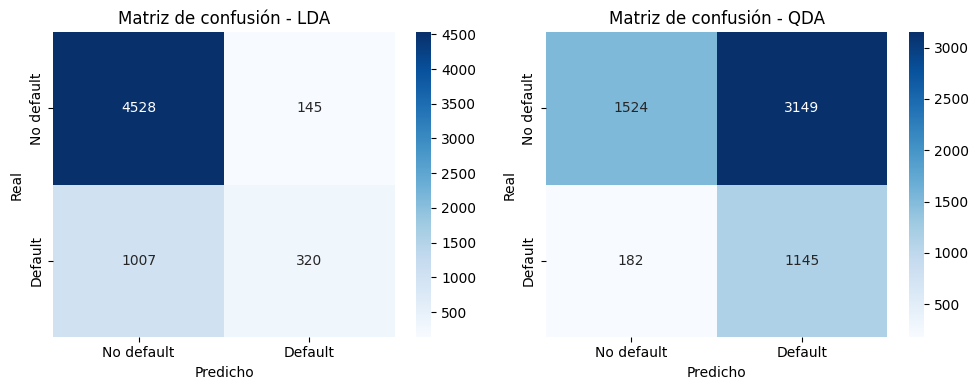

In [16]:
# Matrices de confusión
fig, ax = plt.subplots(1,2, figsize = (10,4))
for a, y_pred, t in zip(ax, [y_pred_lda, y_pred_qda], ['LDA', 'QDA']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', ax = a,
               xticklabels = ['No default', 'Default'],
               yticklabels = ['No default', 'Default'] )
    a.set_title(f'Matriz de confusión - {t}'); a.set_xlabel('Predicho'); a.set_ylabel('Real')
plt.tight_layout()
plt.show()

# Pregunta 10:
# En riesgo crediticio, ¿qué error consideras más grave: falso positivo o falso negativo?

repuesta de la pregunta 10 : El falso negativo es mas grave porque no detecta a un cliente que realmente puede caer en default

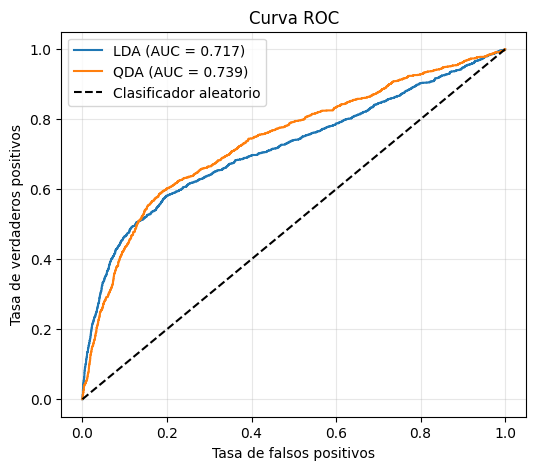

In [17]:
# Curvas ROC y AUC

plt.figure(figsize = (6,5))
for nombre, proba in [('LDA', y_proba_lda), ('QDA', y_proba_qda)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label = f'{nombre} (AUC = {roc_auc_score(y_test, proba):.3f})')

plt.plot([0,1], [0,1], 'k--', label = 'Clasificador aleatorio')
plt.xlabel('Tasa de falsos positivos'); plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC'); plt.legend(); plt.grid(alpha = 0.3)
plt.show()

# Pregunta 11:
# ¿Qué significa que un modelo tenga un AUC mayor?

repuestas de la pregunta 11 : Un AUC mayor indica que el modelo distingue mejor entre las observaciones de cada clase por lo que su capacidad de clasificacion es superior

## 7. Comparación e Interpretación

**Pregunta 12.** Redacta una conclusión comparando LDA y QDA. Considera Accuracy, Precision, Recall, F1-Score, AUC-ROC y la matriz de confusión.

LDA obtuvo mejor Accuracy y Precision mientras que QDA presento mejor Recall y AUC-ROC asi que esto indica que LDA clasifica es mejor en general pero QDA detecta una mayor cantidad de clientes con riesgo de default asu que La eleccion del modelo depende de si se busca mayor exactitud o una mejor deteccion de casos de riesgo


Los resultados muestran que LDA presentó un mejor desempeño general con una exactitud de 0.8080 y una precisión de 0.6882 mientras que QDA obtuvo una exactitud considerablemente menor de 0.4448 y una precisión de 0.2667. Aunque QDA alcanzó un valor ligeramente superior en la métrica F1 con 0.7392 frente a 0.7171 de LDA la diferencia práctica no compensa la pérdida de estabilidad y capacidad predictiva. Esto sugiere que una frontera lineal resulta suficiente para el problema y que la mayor flexibilidad de QDA no necesariamente está generando sobreajuste. En este contexto los errores más relevantes son los falsos negativos debido a que implican clasificar clientes riesgosos como clientes confiables.

**Actividad:** Reescribe este párrafo con tus propias palabras después de ejecutar todo el notebook.

los resultados muestran que LDA tuvo mejor desempeño general ya que obtuvo mayor accuracy y precision. Por otro lado, QDA logro un recall y AUC ROC ligeramente mayores que lo de mas lo que le permite detectar mas casos de default asi que en este problema, LDA parece ser la mejor opcion porque mantiene un mejor equilibrio entre las metricas y comete menos errores de clasificacion y ya que comete menos erroeres nos beneficia mejor a nosotros